In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# -------------------------------
# Scikit-Learn (Machine Learning utilities)
# -------------------------------
from sklearn.model_selection import train_test_split
#  Splits the dataset into training and testing sets to evaluate model performance.

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0]).

In [26]:
df = pd.read_csv('iris.data.csv')

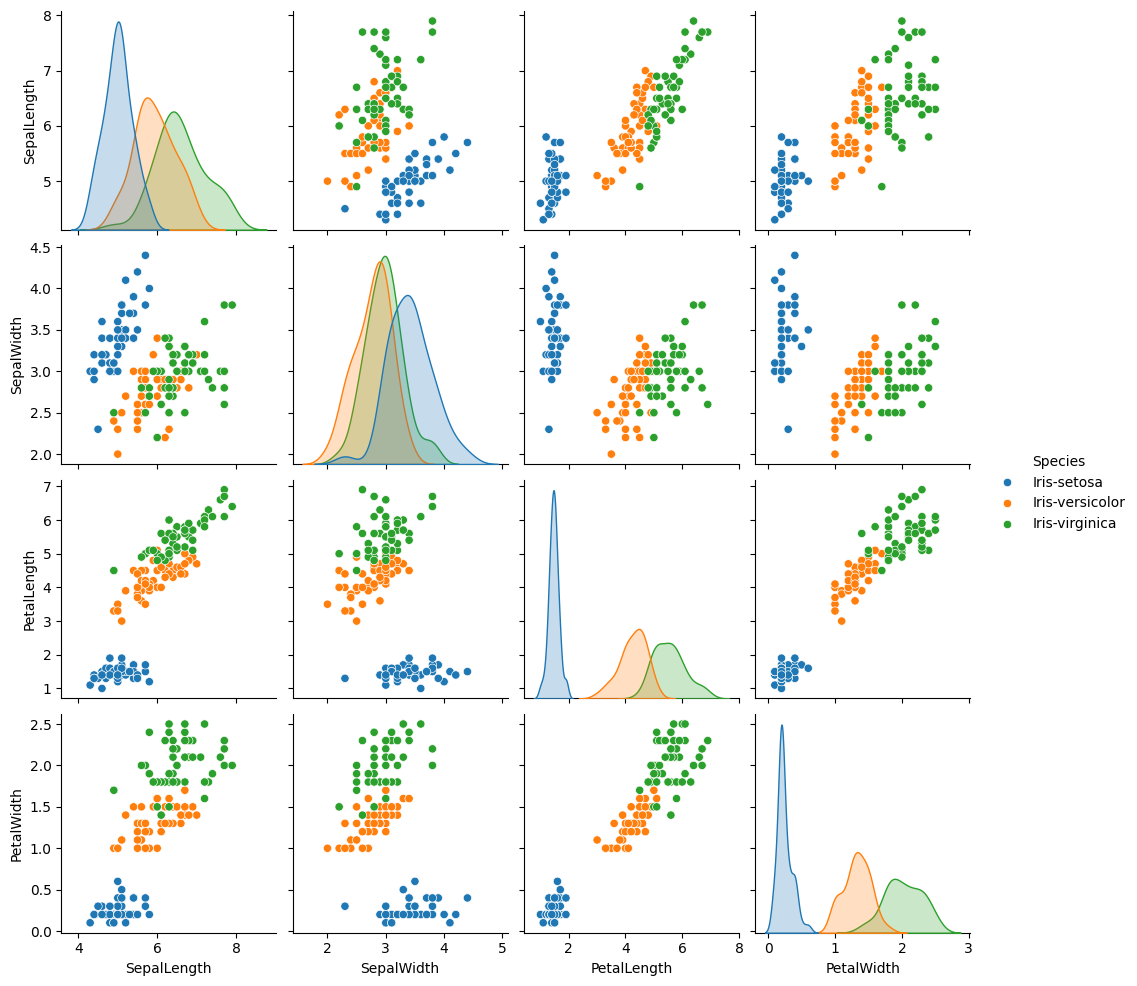

In [27]:
sns.pairplot(df, hue = 'Species')

In [28]:
df

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [90]:
X = df.drop(columns = ['Species'], axis = 1)
y = df['Species']

In [91]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [133]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

In [113]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [114]:
perc = Perceptron(max_iter = 1000, random_state = 42)
perc.fit(X_train, y_train)

Perceptron(random_state=42)

In [115]:
y_pred = perc.predict(X_test)

In [116]:
acc_sc = accuracy_score(y_test, y_pred)
print("Accuracy : ", acc_sc)

Accuracy :  0.84


In [117]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        25
           1       0.71      0.88      0.79        25
           2       1.00      0.64      0.78        25

    accuracy                           0.84        75
   macro avg       0.87      0.84      0.84        75
weighted avg       0.87      0.84      0.84        75



In [135]:
y_train_cat = to_categorical(y_train, num_classes = 3)
y_test_cat = to_categorical(y_test, num_classes = 3)

In [136]:
model = Sequential([
    Input(shape = (4,)),
    Dense(48, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(8, activation = 'relu'),
    Dense(3, activation = 'softmax')
])

In [137]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [138]:
histroy = model.fit(
    X_train, y_train_cat,
    validation_data = (X_test, y_test_cat),
    epochs = 100,
    batch_size = 16,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.3333 - loss: 1.1829 - val_accuracy: 0.3333 - val_loss: 1.1053
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.0929 - val_accuracy: 0.3333 - val_loss: 1.0724
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3333 - loss: 1.0702 - val_accuracy: 0.3333 - val_loss: 1.0524
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.0452 - val_accuracy: 0.3333 - val_loss: 1.0347
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.0277 - val_accuracy: 0.3667 - val_loss: 1.0133
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3917 - loss: 1.0089 - val_accuracy: 0.6000 - val_loss: 0.9919
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5917 - loss: 0.9863 - val_accuracy: 0.6667 - val_loss: 0.9680
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6583 - loss: 0.9583 - val_accuracy: 0.6667 - val_loss:

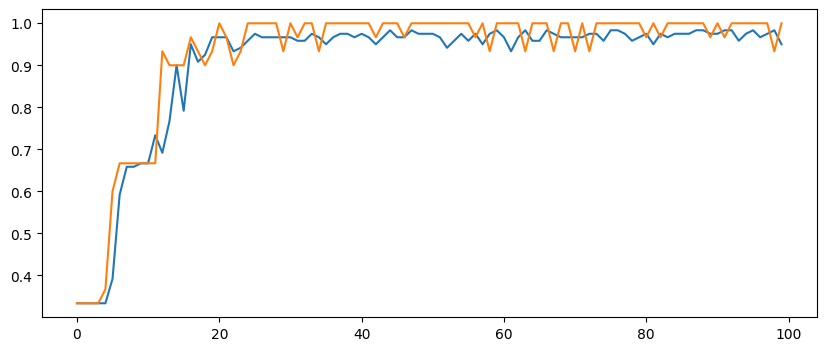

In [139]:
plt.figure(figsize = (10,4))
plt.plot(histroy.history['accuracy'], label = 'train_acc')
plt.plot(histroy.history['val_accuracy'], label = 'test_acc')

In [123]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose = 1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8267 - loss: 0.4194
